In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score , mean_squared_error , root_mean_squared_error
import warnings 
warnings.filterwarnings('ignore')


In [4]:
data = pd.read_csv('Salary_Data_v2.csv')
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
x = data.iloc[:,:-1]
y = data.iloc[:,1]


In [6]:
x_train , x_test , y_train , y_test = train_test_split(x , y ,random_state=10 , train_size=0.8)

#### polynomial regression

In [7]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=15)
x_poly_train = poly.fit_transform(x_train)
x_poly_test = poly.transform(x_test)

poly_model = LinearRegression()
poly_model.fit(x_poly_train , y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
y_poly_train = poly_model.predict(x_poly_train)
y_poly_test = poly_model.predict(x_poly_test)

In [9]:
x_range = np.linspace(x.min() , x.max() , 100).reshape(-1 , 1)

x_range_poly = poly.transform(x_range)
y_range_pred = poly_model.predict(x_range_poly)

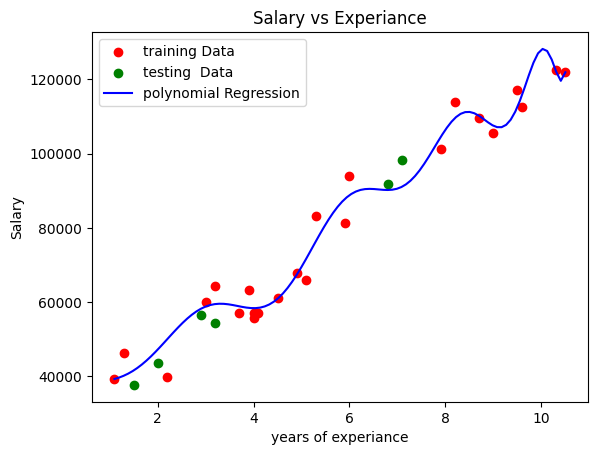

In [10]:
plt.scatter(x_train , y_train, color = 'red' , label = 'training Data')
plt.scatter(x_test , y_test, color = 'green' , label = 'testing  Data')
plt.plot(x_range , y_range_pred , color = 'blue' , label = 'polynomial Regression')
plt.title('Salary vs Experiance')
plt.xlabel('years of experiance')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [11]:
mse = mean_squared_error(y_test , y_poly_test)
root_mse = root_mean_squared_error(y_test , y_poly_test)
print(mse)
print(root_mse)

r2 = r2_score(y_test , y_poly_test)
print(r2)

18439611.603090685
4294.136886859883
0.9654074352130911


# Logistic Regression

In [12]:
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [13]:
x = df.iloc[:,[2,3]].values
y = df.iloc[:,-1].values
y

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,

In [29]:
x_train , x_test , y_train , y_test = train_test_split(x, y , train_size=0.7 , random_state=0)


In [30]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()

x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)


In [31]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
classifier.fit(x_train , y_train)
y_pred = classifier.predict(x_test)


In [67]:
from sklearn.metrics import confusion_matrix, accuracy_score , recall_score , precision_score , f1_score , roc_auc_score

cm = confusion_matrix(y_test , y_pred)
cm

array([[74,  5],
       [11, 30]])

In [63]:
tp = 74
tn = 30
fp = 11
fn = 5

acc = (tn + tp)/(tp + tn + fp + fn)
acc

0.8666666666666667

In [75]:
accuracy_score_ = accuracy_score(y_test , y_pred)
recall_score_ = recall_score(y_test , y_pred)
precision_score_ = precision_score(y_test , y_pred)
f1_score_ = f1_score(y_test , y_pred)

print(f"Accuracy: {accuracy_score_}")
print(f"Recall Score: {recall_score_}")
print(f"precision Score: {precision_score_}")
print(f"F1 Score: {f1_score_}")


Accuracy: 0.8666666666666667
Recall Score: 0.7317073170731707
precision Score: 0.8571428571428571
F1 Score: 0.7894736842105263


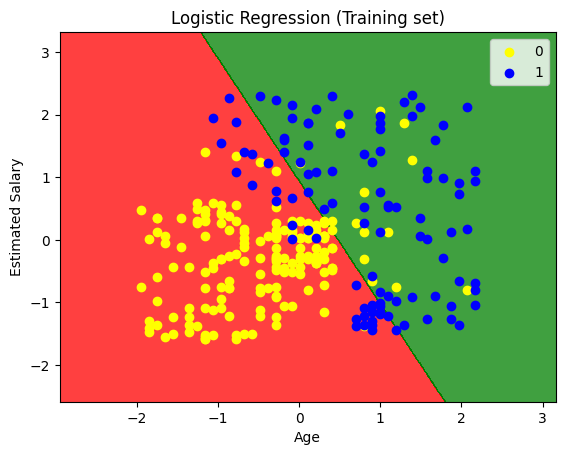

In [80]:
from matplotlib.colors import ListedColormap

X_Set, Y_Set = x_train, y_train

# Create grid
X1, X2 = np.meshgrid(
    np.arange(start=X_Set[:, 0].min() - 1, stop=X_Set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_Set[:, 1].min() - 1, stop=X_Set[:, 1].max() + 1, step=0.01)
)

# Predict on grid
Z = classifier.predict(
    np.array([X1.ravel(), X2.ravel()]).T
)
Z = Z.reshape(X1.shape)

# Plot decision boundary
plt.contourf(X1, X2, Z,
             alpha=0.75,
             cmap=ListedColormap(('red', 'green')))

# Fix axis (IMPORTANT FIX)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plot points
for i, j in enumerate(np.unique(Y_Set)):
    plt.scatter(
        X_Set[Y_Set == j, 0],
        X_Set[Y_Set == j, 1],
        c=ListedColormap(('yellow', 'blue'))(i),
        label=j
    )

plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()